In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
smagnan_1_million_reddit_comments_from_40_subreddits_path = kagglehub.dataset_download('smagnan/1-million-reddit-comments-from-40-subreddits')

print('Data source import complete.')


100%|██████████| 71.2M/71.2M [00:04<00:00, 17.7MB/s]

Extracting files...


Data source import complete.


In [10]:
print(smagnan_1_million_reddit_comments_from_40_subreddits_path)

/root/.cache/kagglehub/datasets/smagnan/1-million-reddit-comments-from-40-subreddits/versions/1


In [8]:
import os
file_list = os.listdir('/root/.cache/kagglehub/datasets/smagnan/1-million-reddit-comments-from-40-subreddits/versions/1')
print(file_list)

['kaggle_RC_2019-05.csv']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


       subreddit                                               body  \
0  gameofthrones  Your submission has been automatically removed...   
1            aww  Dont squeeze her with you massive hand, you me...   
2         gaming  It's pretty well known and it was a paid produ...   
3           news  You know we have laws against that currently c...   
4       politics  Yes, there is a difference between gentle supp...   

   controversiality  score  
0                 0      1  
1                 0     19  
2                 0      3  
3                 0     10  
4                 0      1  
Index(['subreddit', 'body', 'controversiality', 'score'], dtype='object')


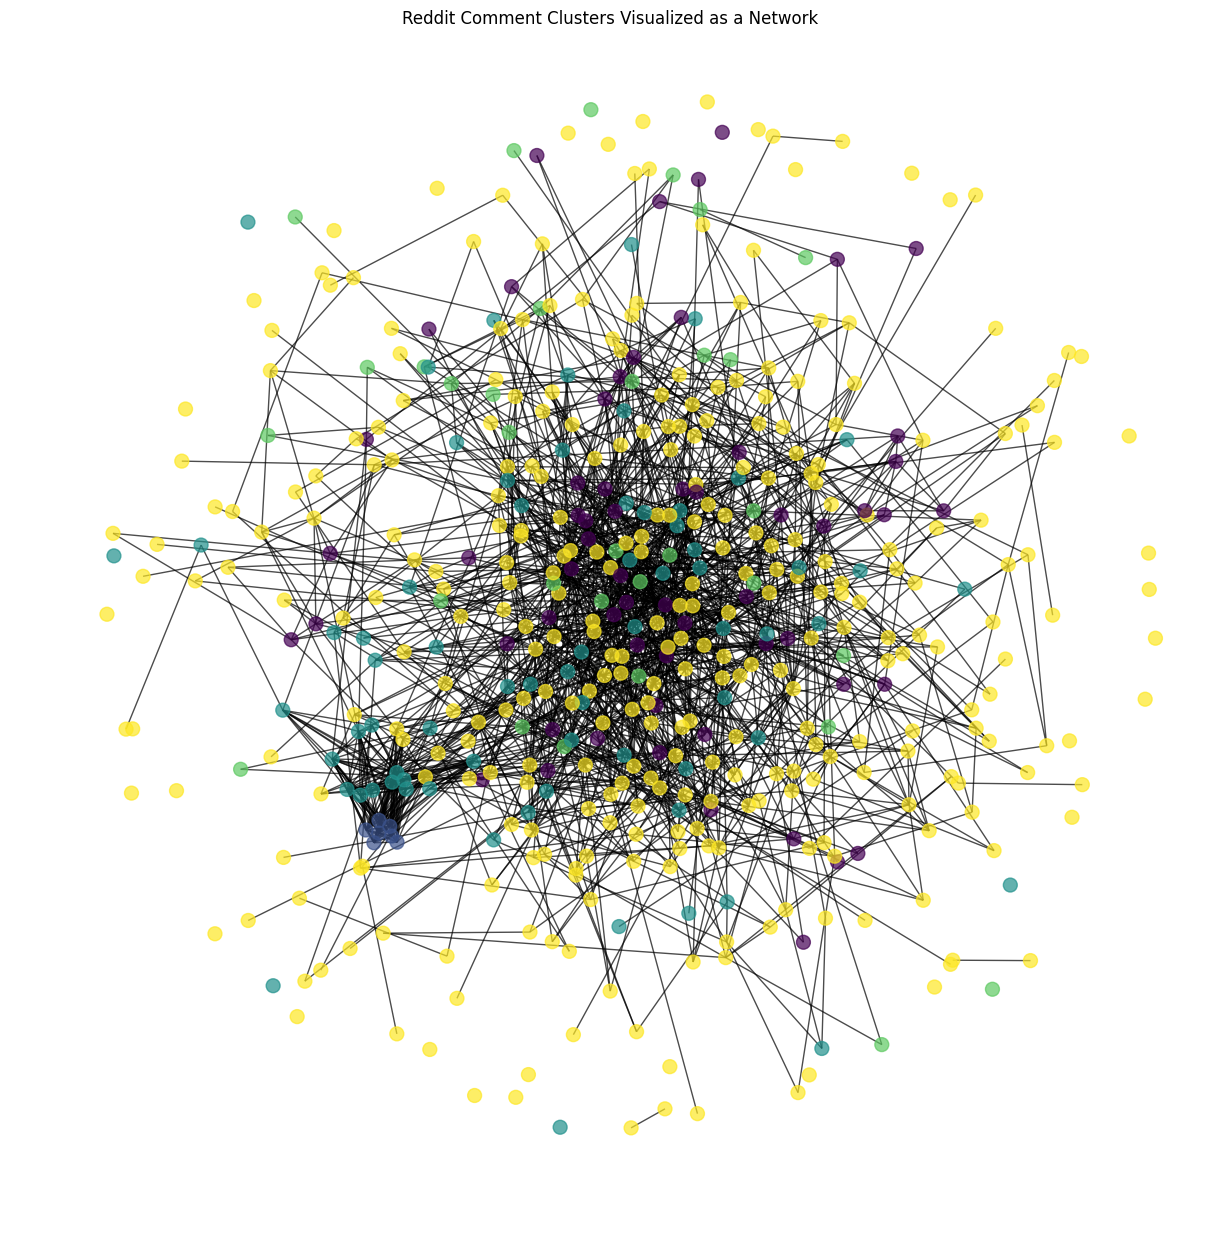


Cluster 1:
Top words: like, say, fucking, good, wait

Cluster 2:
Top words: dank, comment, downvote, dankmemes, meme

Cluster 3:
Top words: one, need, better, please, use

Cluster 4:
Top words: got, see, source, random, anyone

Cluster 5:
Top words: get, would, think, people, time
                                                     body  cluster
987231  How ironic that you're being indignant on the ...        2
79954   I started work in 99 when the boomers we're st...        4
567130  Any combination of the following:\n\nAAE Pump ...        3
500891  Compare pharma's marketing budget to it's R&am...        4
55399                 Wasn't it an illegitimate election?        4
...                                                   ...      ...
332468                       Тогда и "Аэроплан" до кучи )        4
629264  I get the impression, that there is an insecur...        4
566363             Except the one that wears a red shirt.        2
577929  In the scene, the guy is in the high sc

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report
import nltk
from nltk.corpus import stopwords
import warnings
import os

# Suppress the warnings about CPU cores (optional)
warnings.filterwarnings("ignore", message=".*Could not find the number of physical cores.*")
# Set the number of CPU cores to use (optional)
os.environ["LOKY_MAX_CPU_COUNT"] = "2"  # Adjust this number based on your system

# Download stopwords from nltk
nltk.download('stopwords')

# Load the Reddit Comments dataset (adjust path if necessary)
df = pd.read_csv("/root/.cache/kagglehub/datasets/smagnan/1-million-reddit-comments-from-40-subreddits/versions/1/kaggle_RC_2019-05.csv")  # Replace with the correct path to your dataset

# Preview the dataset
print(df.head())

# Check column names to find the comment column
print(df.columns)

# Select only the 'body' column (this is where the comment text is)
df = df[['body']]  # 'body' contains the comment text

# Sample 500 random comments from the dataset
df_sampled = df.sample(n=500, random_state=42)  # Adjust n for a different number of comments if needed

# Remove stopwords and other non-essential words
stop_words = stopwords.words('english')

# TF-IDF Vectorization to convert text into numerical representation
vectorizer = TfidfVectorizer(stop_words=stop_words)
X = vectorizer.fit_transform(df_sampled['body'])  # Use 'body' column for text data

# Set the number of clusters (topics)
k = 5  # You can adjust this number for the number of topics you'd like to cluster into

# Fit the K-means model
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

# Get the cluster assignments for each comment
df_sampled['cluster'] = kmeans.labels_

# Create a graph using networkx
G = nx.Graph()

# Add nodes (each comment is a node) and assign cluster labels as node attributes
for i in range(len(df_sampled)):  # Use integer indices as node identifiers
    cluster_label = df_sampled.iloc[i]['cluster']
    G.add_node(i, label=cluster_label, text=df_sampled.iloc[i]['body'])

# Compute the cosine similarity between all pairs of comments
cosine_sim = cosine_similarity(X)

# Add edges to the graph based on similarity threshold
threshold = 0.1  # You can adjust this threshold for sparsity of the graph
for i in range(cosine_sim.shape[0]):
    for j in range(i + 1, cosine_sim.shape[0]):
        if cosine_sim[i, j] > threshold:
            G.add_edge(i, j, weight=cosine_sim[i, j])

# Draw the graph
plt.figure(figsize=(12, 12))

# Set the node colors based on the cluster labels
node_colors = [G.nodes[node]['label'] for node in G.nodes]

# Use spring layout for visualization
pos = nx.spring_layout(G, k=0.15, iterations=50)

# Draw the graph
nx.draw(G, pos, with_labels=False, node_size=100, node_color=node_colors, cmap=plt.cm.viridis, alpha=0.7)
plt.title("Reddit Comment Clusters Visualized as a Network")
plt.show()

# Get the top terms for each cluster
terms = vectorizer.get_feature_names_out()
num_top_words = 5
for i in range(k):
    print(f"\nCluster {i + 1}:")
    cluster_center = kmeans.cluster_centers_[i]
    top_indices = cluster_center.argsort()[-num_top_words:][::-1]
    top_terms = [terms[index] for index in top_indices]
    print("Top words:", ", ".join(top_terms))

# Save the results to a CSV file
df_sampled.to_csv("reddit_comments_sampled_clustered.csv", index=False)

# Show the dataframe with cluster assignments
print(df_sampled)

# Now, create a test dataset for evaluating the clustering model
# Here, we will simulate the process by randomly splitting the sampled dataset into training and test sets
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df_sampled, test_size=0.2, random_state=42)

# Transform the test set using the same TF-IDF vectorizer
X_test = vectorizer.transform(df_test['body'])

# Predict the clusters for the test set
y_pred = kmeans.predict(X_test)

# Print out the classification report for accuracy, precision, recall, and F1-score
print("\nClassification report for predicted clusters on test data:")
print(classification_report(df_test['cluster'], y_pred, zero_division=1))

# Check if there are empty clusters in the test set (clusters with no predicted samples)
predicted_cluster_counts = pd.Series(y_pred).value_counts()
print("\nPredicted cluster distribution in the test set:")
print(predicted_cluster_counts)

